# Bandwidth vs. Risetime

Original author: David Banas <capn.freako@gmail.com>  
Original date: April 7, 2026

Copyright &copy; 2026 David Banas; all rights reserved World wide.

## Notebook Description

This Jupyter notebook is used to explore the relationship between _edge risetime_ and resultant _signal bandwidth_, for the _error function_.
The _error function_ is chosen because it has a Gaussian edge shape, which is most apropos when attempting to model real World signals.
Predictions are generated both analytically and experimentally, using Python code, and compared.

## Analysis

In this section, we use algebraic analysis to understand the relationship between edge risetime and signal bandwidth for a Gaussian shaped edge.


### Gaussian Edge Shape

We'll use the _error function_ as our source of a Gaussian shaped edge, as it posesses several nice properties:

- inherent d.c. balance, due to odd symmetry,
- symmetric and Gaussian shaped corners,
- passes through the origin, and
- a well known Fourier transform result.

The error function and its Fourier transform are taken as:

$$
\text{erf} (t) <=> -\frac{j}{f} e^{- \pi^2 f^2}
$$

The error function is non-analytic, but has been tabulated by several sources.
Because of its odd symmetry, it is only necessary to find its 90% point (i.e. - the time at which the error function passes through 0.8) and double that value to get the 10% - 90% risetime:

$$
\begin{eqnarray}
\text{erf}^{-1}(0.8) &=& 0.9 \\
t_r &=& 1.8
\end{eqnarray}
$$

We can't use the given Fourier transform of the error function, to calculate the -3dB bandwidth of its spectrum, because it goes to infinity at $f = 0$.
And we, therefore, have no reference for calculating "-3dB".

However, if we take the error function (appropriately shifted and scaled) to be the step response of some hypothetical LTI network, then we can differentiate it, to get that network's _impulse response_.
And we know that the impulse and frequency responses form a Fourier transform pair.
Let's try this and see how far we get...

$$
h(t) = \frac{d}{dt} 0.5 \left( \text{erf} (t) + 1 \right) = 0.5 \frac{d}{dt} \text{erf} (t)
$$

But, what is $\frac{d}{dt} \text{erf} (t)$?

The error function is defined (for positive t) as:

$$
\text{erf} (t) = \frac{2}{\sqrt{\pi}} \int_0^t e^{-x^2} dx
$$

(It's defined for negative t, by applying odd symmetry.)

So:

$$
\frac{d}{dt} \text{erf} (t) = \frac{2}{\sqrt{\pi}} \frac{d}{dt} \int_0^t e^{-x^2} dx = \frac{2}{\sqrt{\pi}} e^{-t^2}
$$

And we have:

$$
h(t) = \frac{e^{-t^2}}{\sqrt{\pi}}
$$

We have, from well known tables of Fourier transform pairs:

$$
\mathbb{F} \{e^{-t^2} \} = \sqrt{\pi} \, e^{-\pi^2 f^2}
$$

And, so:

$$
H(f) \equiv \mathbb{F} \{ h(t) \} = e^{-\pi^2 f^2}
$$

$H(f)$ is clearly one at $f = 0$.
So, solving for $H(f) = 0.7$:

$$
\begin{eqnarray}
e^{-\pi^2 f^2} &=& 0.7 \\
\pi^2 f^2 &=& -\ln{0.7} \\
f_{-3dB} &=& \frac{\sqrt{-\ln{0.7}}}{\pi} \approx 0.19
\end{eqnarray}
$$

And, finally, calculating the risetime-bandwidth product:

$$
t_r \cdot f_{-3dB} = 1.8 \cdot 0.19 \approx 0.34
$$

This final calculated factor may then be used to convert from risetime to bandwidth and vice-versa, via:

$$
\begin{eqnarray}
t_r &=& \frac{0.34}{f_{-3dB}} \\
f_{-3dB} &=& \frac{0.34}{t_r}
\end{eqnarray}
$$


## Experiment

Here, we repeat the analysis above experimentally, using Python code, as a check on our calculations.


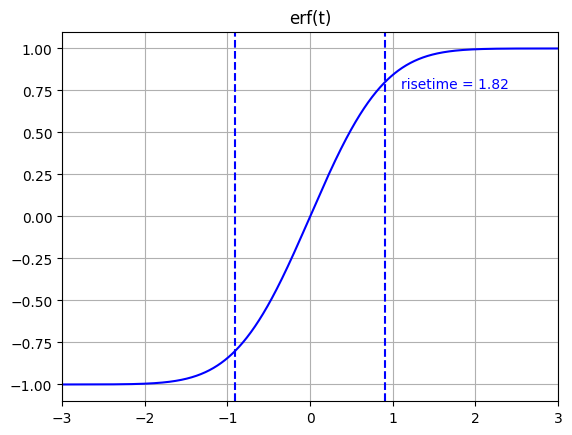

In [19]:
%matplotlib inline

from math       import erf
from matplotlib import pyplot as plt

x_lim = 20
x = np.linspace(-x_lim, x_lim, 8192)
ug = np.array([erf(_x) for _x in x])

ug_10 = np.where(ug > -0.8)[0][0]
ug_90 = np.where(ug >  0.8)[0][0]
ug_tr = x[ug_90] - x[ug_10]

plt.plot(x, ug, "b", label="erf")
plt.axvline(x[ug_10], color="blue", linestyle="dashed")
plt.axvline(x[ug_90], color="blue", linestyle="dashed")
plt.text(1.1, 0.76, f"risetime = {ug_tr:0.2f}", color="blue")

plt.title("erf(t)")
plt.axis(xmin=-3, xmax=3)
plt.grid()
plt.show()


And we see that our measured risetime for the error function edge agrees with our analytical prediction of 1.8.

Let's look at the bandwidth...

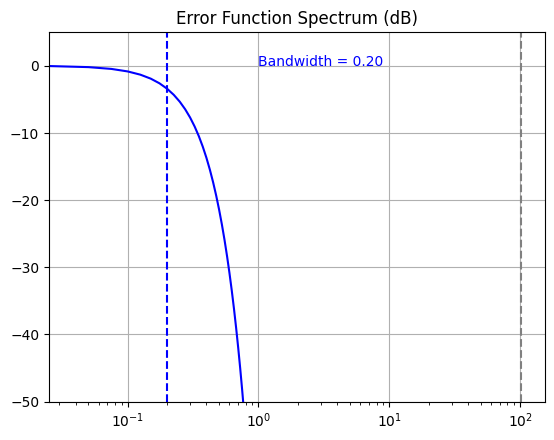

In [20]:
# Calculate the frequency vector for indexing `rfft()` results.
dx = x[1] - x[0]        # delta-t
f0 = 1 / (dx * len(x))  # fundamental frequency
fN = 0.5 / dx           # Nyquist frequency
f = np.arange(0, fN + f0, f0)  # " + f0" just ensures that `fN` will actually be included as the last point.

# As above, calculate the frequency response by taking the Fourier transform
# of the impulse response, which is the derivative of the step response.
h = np.insert(np.diff(0.5 * (ug + 1)), 0, 0)  # impulse response
H = np.abs(np.fft.rfft(h))   # frequency response mag.
bw = f[np.where(H <= 0.7)[0][0]]

# Plot the results.
plt.semilogx(f, 20 * np.log10(np.abs(H)), color="blue")
plt.axvline(bw, color="blue", linestyle="dashed")
plt.axvline(fN, color="gray", linestyle="dashed")
plt.text(1, 0,  f"Bandwidth = {bw:0.2f}", color="blue")
plt.title("Error Function Spectrum (dB)")
plt.axis(xmin=f0, ymin=-50, ymax=5)
plt.grid()
plt.show()


In [21]:
print("Risetime-Bandwidth Products:")
print("============================")
print(f"\terf(t):\t{ug_tr * bw:0.2f}")
# print(f"\tRaised Cosine:\t{uc_tr * UC_bw:0.2f}")


Risetime-Bandwidth Products:
	erf(t):	0.36


## Closing Remarks

We find that both the simulated risetime and bandwidth of the _error function_ agree excellently with our analytical predictions.
And this yields a risetime-bandwidth product of: 0.35, which is precisely in line with our historical professional experience.
